In [3]:
from pathlib import Path
import json
import os
import sys
import tempfile
import warnings

import joblib
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlflow.tracking import MlflowClient

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier


warnings.filterwarnings(
    "ignore"
)


RANDOM_STATE = 42


print(
    "MLflow:",
    mlflow.__version__
)

print(
    "Python:",
    sys.version
)

c:\Users\kwyo1\miniconda3\envs\6550_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow: 3.16.0
Python: 3.11.16 | packaged by conda-forge | (main, Sep  2 2026, 23:31:17) [MSC v.1944 64 bit (AMD64)]


In [4]:
# ============================================================
# PROJECT PATHS
# ============================================================

cwd = Path.cwd()


if cwd.name.lower() == "notebooks":

    PROJECT_ROOT = (
        cwd.parent
    )

else:

    PROJECT_ROOT = (
        cwd
    )


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ai4i2020.csv"
)


# ------------------------------------------------------------
# 03 OUTPUTS
# ------------------------------------------------------------

MODEL_COMPARISON_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_comparison.csv"
)


THRESHOLD_SWEEP_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "threshold_sweep.csv"
)


ASSET_MAPPING_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "asset_failure_risks.csv"
)


REPRESENTATIVE_METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "representative_asset_metadata.json"
)


# ------------------------------------------------------------
# MODEL ARTIFACTS
# ------------------------------------------------------------

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)


BEST_MODEL_PATH = (
    MODEL_DIR
    / "best_model.joblib"
)


RF_MODEL_PATH = (
    MODEL_DIR
    / "random_forest_candidate.joblib"
)


XGB_MODEL_PATH = (
    MODEL_DIR
    / "xgboost_candidate.joblib"
)


MODEL_METADATA_PATH = (
    MODEL_DIR
    / "model_selection_metadata.json"
)


# ------------------------------------------------------------
# MLFLOW
# ------------------------------------------------------------

MLFLOW_DB_PATH = (
    PROJECT_ROOT
    / "mlflow.db"
)


MLFLOW_ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "mlflow_artifacts"
)


MLFLOW_ARTIFACT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Project root:"
)

print(
    PROJECT_ROOT.resolve()
)


print(
    "\nMLflow database:"
)

print(
    MLFLOW_DB_PATH.resolve()
)


print(
    "\nMLflow artifacts:"
)

print(
    MLFLOW_ARTIFACT_ROOT.resolve()
)

Project root:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI

MLflow database:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\mlflow.db

MLflow artifacts:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\mlflow_artifacts


In [5]:
# ============================================================
# VERIFY 03 OUTPUTS
# ============================================================

required_files = [

    DATA_PATH,

    MODEL_COMPARISON_PATH,

    THRESHOLD_SWEEP_PATH,

    BEST_MODEL_PATH,

    RF_MODEL_PATH,

    XGB_MODEL_PATH,

    MODEL_METADATA_PATH,

    ASSET_MAPPING_PATH,

    REPRESENTATIVE_METADATA_PATH,
]


missing_files = [

    path

    for path
    in required_files

    if not path.exists()
]


if missing_files:

    print(
        "Missing files:"
    )

    for path in (
        missing_files
    ):

        print(
            " -",
            path
        )


    raise FileNotFoundError(
        "Run 03_model_selection.ipynb "
        "before running 04."
    )


print(
    "All required 03 artifacts found."
)

All required 03 artifacts found.


In [6]:
# ============================================================
# LOAD 03 RESULTS
# ============================================================

df = pd.read_csv(
    DATA_PATH
)


model_comparison = (
    pd.read_csv(
        MODEL_COMPARISON_PATH
    )
)


threshold_sweep = (
    pd.read_csv(
        THRESHOLD_SWEEP_PATH
    )
)


asset_mapping = (
    pd.read_csv(
        ASSET_MAPPING_PATH
    )
)


with open(
    MODEL_METADATA_PATH,
    "r",
    encoding="utf-8"
) as file:

    model_metadata = (
        json.load(
            file
        )
    )


with open(
    REPRESENTATIVE_METADATA_PATH,
    "r",
    encoding="utf-8"
) as file:

    representative_metadata = (
        json.load(
            file
        )
    )


print(
    "Selected Model:",
    model_metadata[
        "selected_model"
    ]
)


print(
    "Operating Threshold:",
    model_metadata[
        "selected_threshold"
    ]
)


print(
    "\n03 Model Comparison:"
)


display(
    model_comparison
)


print(
    "\nRepresentative Assets:"
)


display(
    asset_mapping
)

Selected Model: XGBoost
Operating Threshold: 0.81

03 Model Comparison:


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Selected
0,XGBoost,0.81,0.983,0.793103,0.676471,0.730159,0.971182,0.795262,True
1,Random Forest,0.55,0.975,0.666667,0.529412,0.590164,0.959692,0.713359,False



Representative Assets:


,Asset ID,Source Row,Failure Risk,Risk Level,Failure Alert,Actual Failure
0,M01,4120,0.903044,CRITICAL,ALERT,1
1,M02,4632,0.866431,CRITICAL,ALERT,1
2,M03,8607,0.792101,HIGH,NORMAL,0
3,M04,3592,0.782492,HIGH,NORMAL,0
4,M05,7682,0.404143,MEDIUM,NORMAL,0
5,M06,8025,0.403049,MEDIUM,NORMAL,0
6,M07,8603,0.081999,LOW,NORMAL,0
7,M08,9986,0.077670,LOW,NORMAL,0
8,M09,4525,0.004501,LOW,NORMAL,0
9,M10,3571,0.004303,LOW,NORMAL,0


In [7]:
# ============================================================
# FEATURES
# ============================================================

FEATURE_COLUMNS = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]


TARGET_COLUMN = (
    "Machine failure"
)


CATEGORICAL_FEATURES = [
    "Type"
]


NUMERIC_FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]


X = (
    df[
        FEATURE_COLUMNS
    ]
    .copy()
)


y = (
    df[
        TARGET_COLUMN
    ]
    .copy()
)


print(
    "Dataset:",
    X.shape
)


print(
    "Failure rate:",
    f"{y.mean():.4f}"
)

Dataset: (10000, 6)
Failure rate: 0.0339


In [8]:
# ============================================================
# REPRODUCE 03 DATA SPLITS
# ============================================================

X_train_full, X_test, y_train_full, y_test = (
    train_test_split(
        X,
        y,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=y
    )
)


X_train, X_val, y_train, y_val = (
    train_test_split(
        X_train_full,
        y_train_full,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=y_train_full
    )
)


print(
    "Train:",
    len(
        X_train
    )
)


print(
    "Validation:",
    len(
        X_val
    )
)


print(
    "Test:",
    len(
        X_test
    )
)


print(
    "\nFailure rates:"
)


print(
    f"Train:      "
    f"{y_train.mean():.4f}"
)


print(
    f"Validation: "
    f"{y_val.mean():.4f}"
)


print(
    f"Test:       "
    f"{y_test.mean():.4f}"
)

Train: 6400
Validation: 1600
Test: 2000

Failure rates:
Train:      0.0339
Validation: 0.0338
Test:       0.0340


In [9]:
# ============================================================
# PREPROCESSOR
# ============================================================

def make_preprocessor():

    return ColumnTransformer(
        transformers=[
            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore"
                ),

                CATEGORICAL_FEATURES
            ),

            (
                "numeric",

                "passthrough",

                NUMERIC_FEATURES
            ),
        ]
    )


# ============================================================
# CLASS IMBALANCE
# ============================================================

negative_count = int(
    (
        y_train
        ==
        0
    ).sum()
)


positive_count = int(
    (
        y_train
        ==
        1
    ).sum()
)


scale_pos_weight = (
    negative_count
    /
    positive_count
)


print(
    "scale_pos_weight:",
    scale_pos_weight
)


# ============================================================
# RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            make_preprocessor()
        ),

        (
            "model",

            RandomForestClassifier(
                n_estimators=300,

                max_depth=None,

                class_weight="balanced",

                random_state=RANDOM_STATE,

                n_jobs=-1
            )
        ),
    ]
)


# ============================================================
# XGBOOST
# ============================================================

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            make_preprocessor()
        ),

        (
            "model",

            XGBClassifier(
                n_estimators=400,

                max_depth=4,

                learning_rate=0.05,

                subsample=0.80,

                colsample_bytree=0.80,

                min_child_weight=1,

                reg_lambda=1.0,

                scale_pos_weight=(
                    scale_pos_weight
                ),

                objective="binary:logistic",

                eval_metric="logloss",

                random_state=RANDOM_STATE,

                n_jobs=-1,

                tree_method="hist"
            )
        ),
    ]
)


candidate_models = {

    "Random Forest":
        rf_pipeline,

    "XGBoost":
        xgb_pipeline,
}

scale_pos_weight: 28.493087557603687


In [10]:
# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold
):

    predictions = (
        np.asarray(
            probabilities
        )
        >=
        threshold
    ).astype(int)


    return {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "average_precision":
            average_precision_score(
                y_true,
                probabilities
            ),
    }


# ============================================================
# THRESHOLD TUNING
# ============================================================

THRESHOLD_GRID = (
    np.round(
        np.arange(
            0.05,
            0.951,
            0.01
        ),
        2
    )
)


def tune_threshold(
    y_true,
    probabilities
):

    rows = []


    for threshold in (
        THRESHOLD_GRID
    ):

        metrics = (
            calculate_metrics(
                y_true,
                probabilities,
                threshold
            )
        )


        rows.append(
            {
                "threshold":
                    float(
                        threshold
                    ),

                **metrics,
            }
        )


    results = (
        pd.DataFrame(
            rows
        )
    )


    best_row = (
        results
        .sort_values(
            [
                "f1",
                "recall",
                "precision",
            ],

            ascending=[
                False,
                False,
                False,
            ]
        )
        .iloc[0]
    )


    return (
        float(
            best_row[
                "threshold"
            ]
        ),

        results
    )

In [11]:
# ============================================================
# MLFLOW TRACKING SETUP
# ============================================================

TRACKING_URI = (
    "sqlite:///"
    +
    MLFLOW_DB_PATH
    .resolve()
    .as_posix()
)


mlflow.set_tracking_uri(
    TRACKING_URI
)


EXPERIMENT_NAME = (
    "MaintenRoute_AI_Model_Selection"
)


client = (
    MlflowClient()
)


existing_experiment = (
    mlflow.get_experiment_by_name(
        EXPERIMENT_NAME
    )
)


if existing_experiment is None:

    EXPERIMENT_ID = (
        client.create_experiment(
            name=(
                EXPERIMENT_NAME
            ),

            artifact_location=(
                MLFLOW_ARTIFACT_ROOT
                .resolve()
                .as_uri()
            ),
        )
    )

else:

    EXPERIMENT_ID = (
        existing_experiment
        .experiment_id
    )


mlflow.set_experiment(
    EXPERIMENT_NAME
)


print(
    "MLflow Tracking URI:"
)

print(
    mlflow.get_tracking_uri()
)


print(
    "\nExperiment:"
)

print(
    EXPERIMENT_NAME
)


print(
    "\nExperiment ID:"
)

print(
    EXPERIMENT_ID
)

2026/09/11 21:34:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/11 21:34:46 INFO mlflow.store.db.utils: Updating database tables


MLflow Tracking URI:
sqlite:///C:/Users/kwyo1/OneDrive/Desktop/ABB/MaintenRouteAI/mlflow.db

Experiment:
MaintenRoute_AI_Model_Selection

Experiment ID:
1


In [12]:
# ============================================================
# MODEL PARAMETERS TO TRACK
# ============================================================

MODEL_PARAMETERS = {

    "Random Forest": {

        "model_type":
            "RandomForestClassifier",

        "n_estimators":
            300,

        "max_depth":
            "None",

        "class_weight":
            "balanced",

        "random_state":
            RANDOM_STATE,

        "preprocessing":
            "OneHot(Type)+NumericPassthrough",
    },


    "XGBoost": {

        "model_type":
            "XGBClassifier",

        "n_estimators":
            400,

        "max_depth":
            4,

        "learning_rate":
            0.05,

        "subsample":
            0.80,

        "colsample_bytree":
            0.80,

        "min_child_weight":
            1,

        "reg_lambda":
            1.0,

        "scale_pos_weight":
            float(
                scale_pos_weight
            ),

        "objective":
            "binary:logistic",

        "tree_method":
            "hist",

        "random_state":
            RANDOM_STATE,

        "preprocessing":
            "OneHot(Type)+NumericPassthrough",
    },
}

In [13]:
# ============================================================
# RUN TRACKED MODEL EXPERIMENTS
# ============================================================

tracked_results = []

candidate_run_ids = {}


for (
    model_name,
    pipeline
) in (
    candidate_models.items()
):

    print(
        "=" * 70
    )

    print(
        "MLflow Run:",
        model_name
    )


    with mlflow.start_run(
        experiment_id=(
            EXPERIMENT_ID
        ),

        run_name=(
            f"{model_name} Candidate"
        )
    ) as run:


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        pipeline.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_probabilities = (
            pipeline.predict_proba(
                X_val
            )[:, 1]
        )


        (
            selected_threshold,
            threshold_results
        ) = tune_threshold(
            y_val,
            val_probabilities
        )


        validation_metrics = (
            calculate_metrics(
                y_val,
                val_probabilities,
                selected_threshold
            )
        )


        # ----------------------------------------------------
        # TEST
        # ----------------------------------------------------

        test_probabilities = (
            pipeline.predict_proba(
                X_test
            )[:, 1]
        )


        test_metrics = (
            calculate_metrics(
                y_test,
                test_probabilities,
                selected_threshold
            )
        )


        # ----------------------------------------------------
        # PARAMETERS
        # ----------------------------------------------------

        mlflow.log_params(
            MODEL_PARAMETERS[
                model_name
            ]
        )


        mlflow.log_params(
            {
                "feature_count":
                    len(
                        FEATURE_COLUMNS
                    ),

                "train_size":
                    len(
                        X_train
                    ),

                "validation_size":
                    len(
                        X_val
                    ),

                "test_size":
                    len(
                        X_test
                    ),

                "operating_threshold":
                    selected_threshold,

                "threshold_objective":
                    "validation_f1",

                "selection_metric":
                    "validation_average_precision",
            }
        )


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        mlflow.log_metrics(
            {
                "val_accuracy":
                    validation_metrics[
                        "accuracy"
                    ],

                "val_precision":
                    validation_metrics[
                        "precision"
                    ],

                "val_recall":
                    validation_metrics[
                        "recall"
                    ],

                "val_f1":
                    validation_metrics[
                        "f1"
                    ],

                "val_roc_auc":
                    validation_metrics[
                        "roc_auc"
                    ],

                "val_average_precision":
                    validation_metrics[
                        "average_precision"
                    ],

                "test_accuracy":
                    test_metrics[
                        "accuracy"
                    ],

                "test_precision":
                    test_metrics[
                        "precision"
                    ],

                "test_recall":
                    test_metrics[
                        "recall"
                    ],

                "test_f1":
                    test_metrics[
                        "f1"
                    ],

                "test_roc_auc":
                    test_metrics[
                        "roc_auc"
                    ],

                "test_average_precision":
                    test_metrics[
                        "average_precision"
                    ],
            }
        )


        # ----------------------------------------------------
        # TAGS
        # ----------------------------------------------------

        mlflow.set_tags(
            {
                "project":
                    "MaintenRoute AI",

                "task":
                    "predictive maintenance",

                "dataset":
                    "AI4I 2020",

                "stage":
                    "candidate_evaluation",

                "source_notebook":
                    "04_mlflow_tracking",

                "selected_by_03":
                    str(
                        model_name
                        ==
                        model_metadata[
                            "selected_model"
                        ]
                    ).lower(),
            }
        )


        # ----------------------------------------------------
        # LOG MODEL + EVALUATION ARTIFACTS
        # ----------------------------------------------------

        with tempfile.TemporaryDirectory() as temp_dir:

            temp_dir = Path(
                temp_dir
            )


            model_file = (
                temp_dir
                /
                (
                    model_name
                    .lower()
                    .replace(
                        " ",
                        "_"
                    )
                    +
                    "_tracked.joblib"
                )
            )


            joblib.dump(
                pipeline,
                model_file
            )


            mlflow.log_artifact(
                str(
                    model_file
                ),

                artifact_path="model"
            )


            # ----------------------------------------------
            # Threshold CSV
            # ----------------------------------------------

            threshold_file = (
                temp_dir
                /
                "threshold_sweep.csv"
            )


            threshold_results.to_csv(
                threshold_file,
                index=False
            )


            mlflow.log_artifact(
                str(
                    threshold_file
                ),

                artifact_path="evaluation"
            )


            # ----------------------------------------------
            # Threshold Trade-off Plot
            # ----------------------------------------------

            plt.figure(
                figsize=(9, 5)
            )


            plt.plot(
                threshold_results[
                    "threshold"
                ],

                threshold_results[
                    "precision"
                ],

                label="Precision"
            )


            plt.plot(
                threshold_results[
                    "threshold"
                ],

                threshold_results[
                    "recall"
                ],

                label="Recall"
            )


            plt.plot(
                threshold_results[
                    "threshold"
                ],

                threshold_results[
                    "f1"
                ],

                label="F1"
            )


            plt.axvline(
                selected_threshold,

                linestyle="--",

                label=(
                    f"Selected "
                    f"{selected_threshold:.2f}"
                )
            )


            plt.xlabel(
                "Classification Threshold"
            )


            plt.ylabel(
                "Score"
            )


            plt.title(
                f"{model_name} "
                f"Validation Threshold Trade-off"
            )


            plt.ylim(
                0,
                1.05
            )


            plt.grid(
                alpha=0.25
            )


            plt.legend()


            plt.tight_layout()


            threshold_plot = (
                temp_dir
                /
                "threshold_tradeoff.png"
            )


            plt.savefig(
                threshold_plot,
                dpi=150,
                bbox_inches="tight"
            )


            plt.close()


            mlflow.log_artifact(
                str(
                    threshold_plot
                ),

                artifact_path="plots"
            )


            # ----------------------------------------------
            # Test Confusion Matrix
            # ----------------------------------------------

            test_predictions = (
                test_probabilities
                >=
                selected_threshold
            ).astype(int)


            ConfusionMatrixDisplay.from_predictions(
                y_test,
                test_predictions,
                values_format="d"
            )


            plt.title(
                f"{model_name} "
                f"Test Confusion Matrix"
            )


            plt.tight_layout()


            confusion_plot = (
                temp_dir
                /
                "test_confusion_matrix.png"
            )


            plt.savefig(
                confusion_plot,
                dpi=150,
                bbox_inches="tight"
            )


            plt.close()


            mlflow.log_artifact(
                str(
                    confusion_plot
                ),

                artifact_path="plots"
            )


        # ----------------------------------------------------
        # SAVE RESULTS IN NOTEBOOK
        # ----------------------------------------------------

        candidate_run_ids[
            model_name
        ] = (
            run.info.run_id
        )


        tracked_results.append(
            {
                "Model":
                    model_name,

                "Run ID":
                    run.info.run_id,

                "Threshold":
                    selected_threshold,

                "Val Accuracy":
                    validation_metrics[
                        "accuracy"
                    ],

                "Val Precision":
                    validation_metrics[
                        "precision"
                    ],

                "Val Recall":
                    validation_metrics[
                        "recall"
                    ],

                "Val F1":
                    validation_metrics[
                        "f1"
                    ],

                "Val ROC-AUC":
                    validation_metrics[
                        "roc_auc"
                    ],

                "Val Average Precision":
                    validation_metrics[
                        "average_precision"
                    ],

                "Test Accuracy":
                    test_metrics[
                        "accuracy"
                    ],

                "Test Precision":
                    test_metrics[
                        "precision"
                    ],

                "Test Recall":
                    test_metrics[
                        "recall"
                    ],

                "Test F1":
                    test_metrics[
                        "f1"
                    ],

                "Test ROC-AUC":
                    test_metrics[
                        "roc_auc"
                    ],

                "Test Average Precision":
                    test_metrics[
                        "average_precision"
                    ],
            }
        )


        print(
            "Run ID:",
            run.info.run_id
        )


        print(
            "Threshold:",
            selected_threshold
        )


        print(
            "Validation AP:",
            validation_metrics[
                "average_precision"
            ]
        )


        print(
            "Test AP:",
            test_metrics[
                "average_precision"
            ]
        )


        print()

MLflow Run: Random Forest
Run ID: 38fb4aad5ac442899327f0d9a8a7f5c3
Threshold: 0.55
Validation AP: 0.716043903118559
Test AP: 0.7133593843893131

MLflow Run: XGBoost
Run ID: ebecb3ace9d3478c9e2b444edbe7bde8
Threshold: 0.81
Validation AP: 0.7687409057943699
Test AP: 0.7952619075885468



In [14]:
# ============================================================
# TRACKED RESULTS
# ============================================================

tracked_results_df = (
    pd.DataFrame(
        tracked_results
    )
)


display(
    tracked_results_df.style.format(
        {
            "Threshold":
                "{:.2f}",

            "Val Accuracy":
                "{:.4f}",

            "Val Precision":
                "{:.4f}",

            "Val Recall":
                "{:.4f}",

            "Val F1":
                "{:.4f}",

            "Val ROC-AUC":
                "{:.4f}",

            "Val Average Precision":
                "{:.4f}",

            "Test Accuracy":
                "{:.4f}",

            "Test Precision":
                "{:.4f}",

            "Test Recall":
                "{:.4f}",

            "Test F1":
                "{:.4f}",

            "Test ROC-AUC":
                "{:.4f}",

            "Test Average Precision":
                "{:.4f}",
        }
    )
)

,Model,Run ID,Threshold,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Val Average Precision,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Average Precision
0,Random Forest,38fb4aad5ac442899327f0d9a8a7f5c3,0.55,0.9806,0.7805,0.5926,0.6737,0.9630,0.7160,0.9750,0.6667,0.5294,0.5902,0.9597,0.7134
1,XGBoost,ebecb3ace9d3478c9e2b444edbe7bde8,0.81,0.9825,0.7826,0.6667,0.7200,0.9748,0.7687,0.9830,0.7931,0.6765,0.7302,0.9712,0.7953


In [15]:
# ============================================================
# VERIFY MODEL SELECTION
# ============================================================

replay_selection = (
    tracked_results_df
    .sort_values(
        [
            "Val Average Precision",
            "Val F1",
            "Val Recall",
        ],

        ascending=[
            False,
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


replay_selected_model = (
    replay_selection.loc[
        0,
        "Model"
    ]
)


replay_selected_threshold = float(
    replay_selection.loc[
        0,
        "Threshold"
    ]
)


source_selected_model = (
    model_metadata[
        "selected_model"
    ]
)


source_selected_threshold = float(
    model_metadata[
        "selected_threshold"
    ]
)


print(
    "03 Selected Model:",
    source_selected_model
)


print(
    "04 MLflow Replay Selected Model:",
    replay_selected_model
)


print()


print(
    "03 Threshold:",
    source_selected_threshold
)


print(
    "04 Replay Threshold:",
    replay_selected_threshold
)


model_match = (
    replay_selected_model
    ==
    source_selected_model
)


threshold_match = (
    np.isclose(
        replay_selected_threshold,
        source_selected_threshold
    )
)


print(
    "\nModel match:",
    model_match
)


print(
    "Threshold match:",
    threshold_match
)


if (
    not model_match
    or
    not threshold_match
):

    raise RuntimeError(
        "MLflow replay does not match "
        "03_model_selection results."
    )


print(
    "\n✅ MLflow replay successfully "
    "reproduced the frozen 03 selection."
)

03 Selected Model: XGBoost
04 MLflow Replay Selected Model: XGBoost

03 Threshold: 0.81
04 Replay Threshold: 0.81

Model match: True
Threshold match: True

✅ MLflow replay successfully reproduced the frozen 03 selection.


In [16]:
# ============================================================
# DEPLOYMENT REFERENCE RUN
# ============================================================

selected_model_name = (
    model_metadata[
        "selected_model"
    ]
)


selected_threshold = float(
    model_metadata[
        "selected_threshold"
    ]
)


test_metrics = (
    model_metadata[
        "test_metrics"
    ]
)


with mlflow.start_run(
    experiment_id=(
        EXPERIMENT_ID
    ),

    run_name=(
        f"DEPLOYED - "
        f"{selected_model_name}"
    )
) as deployment_run:


    # --------------------------------------------------------
    # PARAMETERS
    # --------------------------------------------------------

    mlflow.log_params(
        {
            "selected_model":
                selected_model_name,

            "operating_threshold":
                selected_threshold,

            "selection_metric":
                "validation_average_precision",

            "threshold_objective":
                "validation_f1",

            "feature_count":
                len(
                    FEATURE_COLUMNS
                ),

            "deployment_artifact":
                "best_model.joblib",

            "representative_sampling":
                (
                    "fixed-seed random sampling "
                    "within risk bands"
                ),
        }
    )


    # --------------------------------------------------------
    # TEST METRICS
    # --------------------------------------------------------

    mlflow.log_metrics(
        {
            "test_accuracy":
                float(
                    test_metrics[
                        "accuracy"
                    ]
                ),

            "test_precision":
                float(
                    test_metrics[
                        "precision"
                    ]
                ),

            "test_recall":
                float(
                    test_metrics[
                        "recall"
                    ]
                ),

            "test_f1":
                float(
                    test_metrics[
                        "f1"
                    ]
                ),

            "test_roc_auc":
                float(
                    test_metrics[
                        "roc_auc"
                    ]
                ),

            # 03 calls this PR-AUC,
            # but it was computed using
            # average_precision_score().
            "test_average_precision":
                float(
                    test_metrics[
                        "pr_auc"
                    ]
                ),
        }
    )


    # --------------------------------------------------------
    # TAGS
    # --------------------------------------------------------

    mlflow.set_tags(
        {
            "project":
                "MaintenRoute AI",

            "stage":
                "deployment_reference",

            "dataset":
                "AI4I 2020",

            "frozen_model":
                "true",

            "candidate_run_id":
                candidate_run_ids[
                    selected_model_name
                ],

            "source_notebook":
                "03_model_selection",

            "tracking_notebook":
                "04_mlflow_tracking",
        }
    )


    # --------------------------------------------------------
    # FROZEN MODEL
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(
            BEST_MODEL_PATH
        ),

        artifact_path="deployment_model"
    )


    # --------------------------------------------------------
    # METADATA
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(
            MODEL_METADATA_PATH
        ),

        artifact_path="metadata"
    )


    mlflow.log_artifact(
        str(
            REPRESENTATIVE_METADATA_PATH
        ),

        artifact_path="metadata"
    )


    # --------------------------------------------------------
    # EVALUATION ARTIFACTS
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(
            MODEL_COMPARISON_PATH
        ),

        artifact_path="evaluation"
    )


    mlflow.log_artifact(
        str(
            THRESHOLD_SWEEP_PATH
        ),

        artifact_path="evaluation"
    )


    # --------------------------------------------------------
    # DEMO ASSETS
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(
            ASSET_MAPPING_PATH
        ),

        artifact_path="demo_assets"
    )


    DEPLOYMENT_RUN_ID = (
        deployment_run
        .info
        .run_id
    )


print(
    "Deployment reference logged."
)


print(
    "Run ID:",
    DEPLOYMENT_RUN_ID
)

Deployment reference logged.
Run ID: 703c963cbc104e419ac2246aa6984528


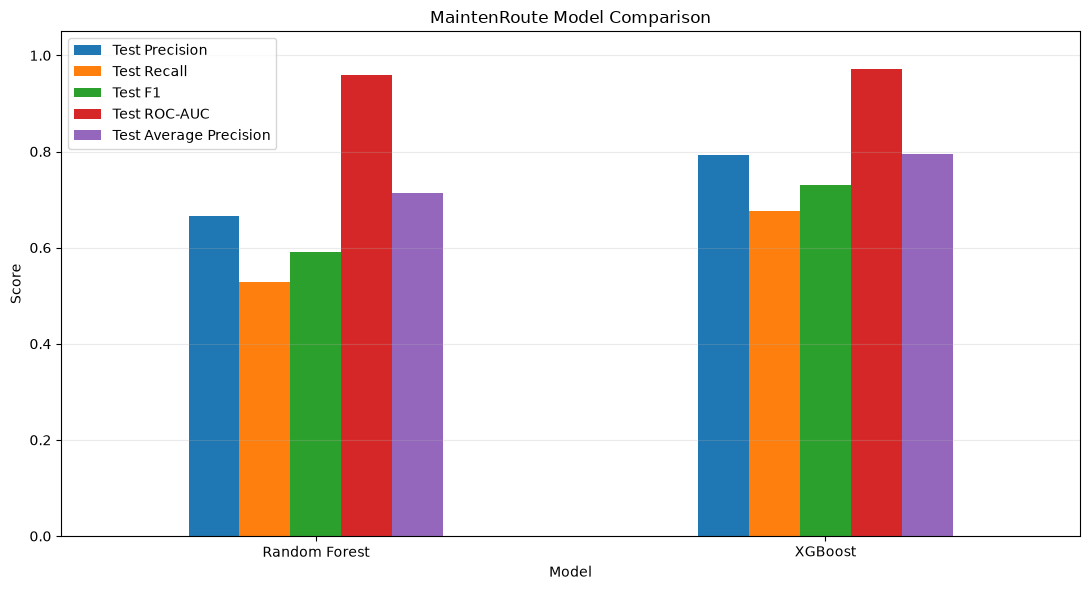

Model comparison plot logged.


In [17]:
# ============================================================
# SHARED MODEL COMPARISON PLOT
# ============================================================

comparison_plot_df = (
    tracked_results_df
    .set_index(
        "Model"
    )
    [
        [
            "Test Precision",
            "Test Recall",
            "Test F1",
            "Test ROC-AUC",
            "Test Average Precision",
        ]
    ]
)


with tempfile.TemporaryDirectory() as temp_dir:

    temp_dir = Path(
        temp_dir
    )


    ax = (
        comparison_plot_df
        .plot(
            kind="bar",
            figsize=(11, 6)
        )
    )


    ax.set_title(
        "MaintenRoute Model Comparison"
    )


    ax.set_ylabel(
        "Score"
    )


    ax.set_ylim(
        0,
        1.05
    )


    ax.grid(
        axis="y",
        alpha=0.25
    )


    plt.xticks(
        rotation=0
    )


    plt.tight_layout()


    comparison_plot_path = (
        temp_dir
        /
        "model_comparison.png"
    )


    plt.savefig(
        comparison_plot_path,
        dpi=150,
        bbox_inches="tight"
    )


    plt.show()


    with mlflow.start_run(
        run_id=(
            DEPLOYMENT_RUN_ID
        )
    ):

        mlflow.log_artifact(
            str(
                comparison_plot_path
            ),

            artifact_path="plots"
        )


print(
    "Model comparison plot logged."
)

In [18]:
# ============================================================
# QUERY MLFLOW RUNS
# ============================================================

runs_df = (
    mlflow.search_runs(
        experiment_ids=[
            EXPERIMENT_ID
        ]
    )
)


print(
    "Number of tracked runs:",
    len(
        runs_df
    )
)


columns_to_show = [

    "run_id",

    "tags.mlflow.runName",

    "tags.stage",

    "params.model_type",

    "params.selected_model",

    "params.operating_threshold",

    "metrics.val_f1",

    "metrics.val_average_precision",

    "metrics.test_precision",

    "metrics.test_recall",

    "metrics.test_f1",

    "metrics.test_average_precision",
]


available_columns = [

    column

    for column
    in columns_to_show

    if column
    in runs_df.columns
]


display(
    runs_df[
        available_columns
    ]
)

Number of tracked runs: 3


,run_id,tags.mlflow.runName,tags.stage,params.model_type,params.selected_model,params.operating_threshold,metrics.val_f1,metrics.val_average_precision,metrics.test_precision,metrics.test_recall,metrics.test_f1,metrics.test_average_precision
0,703c963cbc104e419ac2246aa6984528,DEPLOYED - XGBoost,deployment_reference,NaN,XGBoost,0.81,NaN,NaN,0.793103,0.676471,0.730159,0.795262
1,ebecb3ace9d3478c9e2b444edbe7bde8,XGBoost Candidate,candidate_evaluation,XGBClassifier,NaN,0.81,0.720000,0.768741,0.793103,0.676471,0.730159,0.795262
2,38fb4aad5ac442899327f0d9a8a7f5c3,Random Forest Candidate,candidate_evaluation,RandomForestClassifier,NaN,0.55,0.673684,0.716044,0.666667,0.529412,0.590164,0.713359


In [19]:
# ============================================================
# SAVE TRACKING SUMMARY
# ============================================================

MLFLOW_SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "mlflow_run_summary.csv"
)


runs_df.to_csv(
    MLFLOW_SUMMARY_PATH,
    index=False
)


print(
    "Saved:"
)

print(
    MLFLOW_SUMMARY_PATH.resolve()
)

Saved:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\mlflow_run_summary.csv


In [20]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "=" * 70
)

print(
    "MAINTENROUTE AI"
)

print(
    "MLFLOW EXPERIMENT TRACKING SUMMARY"
)

print(
    "=" * 70
)


print(
    "\nExperiment:"
)

print(
    EXPERIMENT_NAME
)


print(
    "\nTracking URI:"
)

print(
    TRACKING_URI
)


print(
    "\nTracked Candidate Runs:"
)


for (
    model_name,
    run_id
) in (
    candidate_run_ids.items()
):

    print(
        f"  {model_name}: "
        f"{run_id}"
    )


print(
    "\nDeployment Reference Run:"
)

print(
    DEPLOYMENT_RUN_ID
)


print(
    "\nFrozen Deployment Model:"
)

print(
    model_metadata[
        "selected_model"
    ]
)


print(
    "\nOperating Threshold:"
)

print(
    model_metadata[
        "selected_threshold"
    ]
)


print(
    "\n03 / 04 Selection Match:"
)

print(
    model_match
    and
    threshold_match
)


print(
    "\nMLflow Database:"
)

print(
    MLFLOW_DB_PATH.resolve()
)


print(
    "\nArtifacts:"
)

print(
    MLFLOW_ARTIFACT_ROOT.resolve()
)

MAINTENROUTE AI
MLFLOW EXPERIMENT TRACKING SUMMARY

Experiment:
MaintenRoute_AI_Model_Selection

Tracking URI:
sqlite:///C:/Users/kwyo1/OneDrive/Desktop/ABB/MaintenRouteAI/mlflow.db

Tracked Candidate Runs:
  Random Forest: 38fb4aad5ac442899327f0d9a8a7f5c3
  XGBoost: ebecb3ace9d3478c9e2b444edbe7bde8

Deployment Reference Run:
703c963cbc104e419ac2246aa6984528

Frozen Deployment Model:
XGBoost

Operating Threshold:
0.81

03 / 04 Selection Match:
True

MLflow Database:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\mlflow.db

Artifacts:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\mlflow_artifacts


In [21]:
# ============================================================
# MLFLOW UI COMMAND
# ============================================================

if os.name == "nt":

    mlflow_executable = (

        Path(
            sys.executable
        )
        .parent
        /
        "Scripts"
        /
        "mlflow.exe"
    )

else:

    mlflow_executable = (

        Path(
            sys.executable
        )
        .parent
        /
        "bin"
        /
        "mlflow"
    )


print(
    "Run this command in a NEW terminal:"
)

print()


print(
    f'& "{mlflow_executable}" '
    f'server '
    f'--backend-store-uri '
    f'"{TRACKING_URI}" '
    f'--host 127.0.0.1 '
    f'--port 5000'
)


print()

print(
    "Then open:"
)

print(
    "http://127.0.0.1:5000"
)

Run this command in a NEW terminal:

& "c:\Users\kwyo1\miniconda3\envs\6550_env\Scripts\mlflow.exe" server --backend-store-uri "sqlite:///C:/Users/kwyo1/OneDrive/Desktop/ABB/MaintenRouteAI/mlflow.db" --host 127.0.0.1 --port 5000

Then open:
http://127.0.0.1:5000
